# Monte Carlo Pricing of European Options

In this notebook, we implement a Monte Carlo pricer for European options.

The objective is to simulate the terminal stock price under the
Black-Scholes assumptions and compare the Monte Carlo estimate
with the analytical Black-Scholes price.

## Model

Under the Black-Scholes model, the terminal stock price is:

S_T = S0 * exp((r - 0.5 σ²)T + σ√T Z)

where Z follows a standard normal distribution.

## Monte Carlo pricing principle

1. Simulate many possible values of S_T
2. Compute the payoff for each simulation
3. Average the payoffs
4. Discount the result

Price = exp(-rT) * E[payoff]

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import yfinance as yf

## Theoretical framework

Under the Black-Scholes model, the stock price at maturity is given by:

S_T = S_0 * exp((r - 0.5 σ²)T + σ√T Z)

where:
- S_0 is the current stock price
- r is the risk-free rate
- σ is the volatility
- T is the time to maturity
- Z ~ N(0,1)

Once S_T is simulated, the option payoff is computed:

- Call payoff: max(S_T - K, 0)
- Put payoff: max(K - S_T, 0)

The Monte Carlo price is the discounted average payoff.

[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_1011/1152932545.py:10: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  S0 = float(airbus["Adj Close"].iloc[-1])


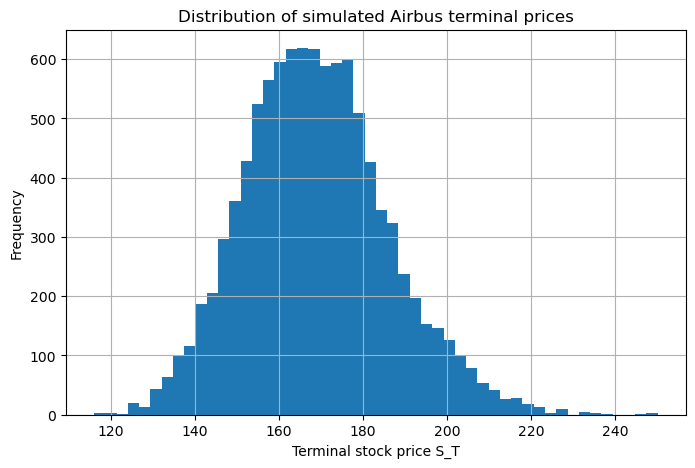

In [2]:
# Airbus market inputs for Monte Carlo

airbus = yf.download("AIR.PA", period="2y", auto_adjust=False)
airbus = airbus[["Adj Close"]].dropna()

airbus["log_return"] = np.log(airbus["Adj Close"] / airbus["Adj Close"].shift(1))
airbus["vol_20d"] = airbus["log_return"].rolling(20).std() * np.sqrt(252)
airbus = airbus.dropna()

S0 = float(airbus["Adj Close"].iloc[-1])
K = round(S0, 2)        # ATM strike based on current Airbus spot
T = 30 / 252
r = 0.02
sigma = float(airbus["vol_20d"].iloc[-1])
N = 10000


# Simulate Airbus terminal prices under Black-Scholes assumptions 
Z = np.random.normal(size=N)

ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

plt.figure(figsize=(8,5))
plt.hist(ST, bins=50)
plt.title("Distribution of simulated Airbus terminal prices")
plt.xlabel("Terminal stock price S_T")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

In [3]:
call_payoff = np.maximum(ST - K, 0)
put_payoff = np.maximum(K - ST, 0)

mc_call = np.exp(-r * T) * np.mean(call_payoff)
mc_put = np.exp(-r * T) * np.mean(put_payoff)

print("Call price is :",mc_call)
print("Put price is :" ,mc_put)

Call price is : 6.9841391133996025
Put price is : 6.572970710004003


In [4]:
# Monte Carlo pricing functions
def mc_call_price(S0, K, T, r, sigma, N):
    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)

def mc_put_price(S0, K, T, r, sigma, N):
    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(K - ST, 0)
    return np.exp(-r * T) * np.mean(payoff)

In [5]:
# Black-Scholes analytical pricing functions
def d1(S, K, T, r, sigma):
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def d2(S, K, T, r, sigma):
    return d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    return S * norm.cdf(d1(S, K, T, r, sigma)) - K * np.exp(-r * T) * norm.cdf(d2(S, K, T, r, sigma))

def bs_put(S, K, T, r, sigma):
    return K * np.exp(-r * T) * norm.cdf(-d2(S, K, T, r, sigma)) - S * norm.cdf(-d1(S, K, T, r, sigma))

## Black-Scholes vs Monte Carlo on Airbus strikes

We compare analytical Black-Scholes prices with Monte Carlo estimates
for strikes around the Airbus at-the-money region.

In [6]:
# Strike grid around ATM
strikes = [round(0.90 * S0, 2),round(0.95 * S0, 2),round(1.00 * S0, 2),round(1.05 * S0, 2),round(1.10 * S0, 2),]
results = []
for K in strikes:
    bs_c = bs_call(S0, K, T, r, sigma)
    mc_c = mc_call_price(S0, K, T, r, sigma, 10000)
    
    bs_p = bs_put(S0, K, T, r, sigma)
    mc_p = mc_put_price(S0, K, T, r, sigma, 10000)
    
    results.append({
        "Strike": K,
        "BS Call": bs_c,
        "MC Call": mc_c,
        "BS Put": bs_p,
        "MC Put": mc_p
    })

comparison_table = pd.DataFrame(results).round(4)
comparison_table

,Strike,BS Call,MC Call,BS Put,MC Put
0,151.61,18.3859,18.3495,1.1754,1.1374
1,160.04,11.9117,11.9207,3.1111,3.0698
2,168.46,6.9715,6.9638,6.5709,6.5097
3,176.88,3.6588,3.6002,11.6581,11.6433
4,185.31,1.7179,1.6686,18.1272,18.0969


## Convergence, confidence intervals and variance reduction

Monte Carlo prices are random estimates.

In this section, we analyse:
- convergence as the number of simulations increases
- confidence intervals
- variance reduction using antithetic variates

In [7]:
def mc_call_price_with_ci(S0, K, T, r, sigma, N):
    """
    Monte Carlo price of a European call option
    with standard error and 95% confidence interval.
    """

    Z = np.random.normal(size=N)
    ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    payoff = np.maximum(ST - K, 0)
    discounted_payoff = np.exp(-r * T) * payoff

    price = np.mean(discounted_payoff)
    std = np.std(discounted_payoff, ddof=1)
    se = std / np.sqrt(N)

    ci_low = price - 1.96 * se
    ci_high = price + 1.96 * se

    return {
        "price": price,
        "std": std,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

### Confidence interval

The Monte Carlo estimator is based on a sample average of discounted payoffs.

Its uncertainty can be measured with a standard error:

SE = std(X) / sqrt(N)

A 95% confidence interval is approximately:

Price ± 1.96 × SE

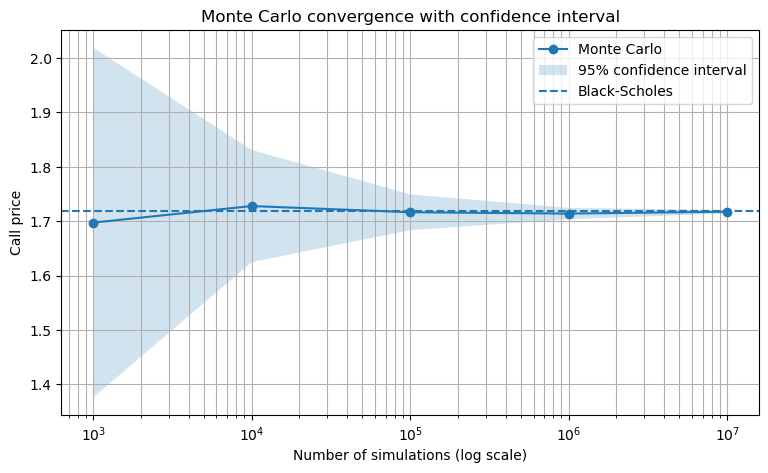

In [8]:
# Convergence analysis with confidence intervals

N_values = [1000 * 10**i for i in range(5)]
bs_price = bs_call(S0, K, T, r, sigma)

convergence_results = []

for N in N_values:
    result = mc_call_price_with_ci(S0, K, T, r, sigma, N)

    convergence_results.append({
        "N simulations": N,
        "MC price": result["price"],
        "SE": result["se"],
        "CI low": result["ci_low"],
        "CI high": result["ci_high"],
        "BS price": bs_price
    })

convergence_table = pd.DataFrame(convergence_results).round(6)
convergence_table




plt.figure(figsize=(9,5))
plt.plot(convergence_table["N simulations"],convergence_table["MC price"],marker="o",label="Monte Carlo")
plt.fill_between(convergence_table["N simulations"],convergence_table["CI low"],convergence_table["CI high"],alpha=0.2,label="95% confidence interval")
plt.axhline(y=bs_price,linestyle="--",label="Black-Scholes")
plt.xscale("log")
plt.title("Monte Carlo convergence with confidence interval")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Call price")
plt.legend()
plt.grid(True, which="both")
plt.show()

In [9]:
def mc_call_price_antithetic(S0, K, T, r, sigma, N):
    """
    Monte Carlo call pricing with antithetic variates.
    N must be even.
    """

    if N % 2 != 0:
        raise ValueError("N must be even for antithetic variates.")

    half_N = N // 2

    # Generate half the shocks
    Z = np.random.normal(size=half_N)

    # Antithetic shocks
    Z_antithetic = -Z

    # Simulate terminal prices
    ST_1 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    ST_2 = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z_antithetic)

    # Compute discounted payoffs
    X_1 = np.exp(-r * T) * np.maximum(ST_1 - K, 0)
    X_2 = np.exp(-r * T) * np.maximum(ST_2 - K, 0)

    # Average each antithetic pair
    pair_average = 0.5 * (X_1 + X_2)

    # Final estimator
    price = np.mean(pair_average)

    # Standard deviation and standard error of the paired estimator
    std = np.std(pair_average, ddof=1)
    se = std / np.sqrt(half_N)

    # 95% confidence interval
    ci_low = price - 1.96 * se
    ci_high = price + 1.96 * se

    return {
        "price": price,
        "std": std,
        "se": se,
        "ci_low": ci_low,
        "ci_high": ci_high
    }

### Antithetic variates

Instead of simulating only random shocks Z, we pair each shock Z
with its opposite value -Z.

This balances positive and negative scenarios and reduces the variance
of the estimator.

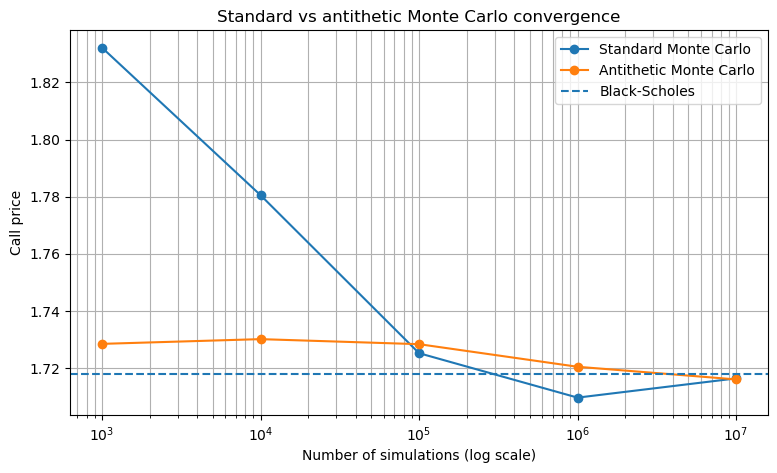

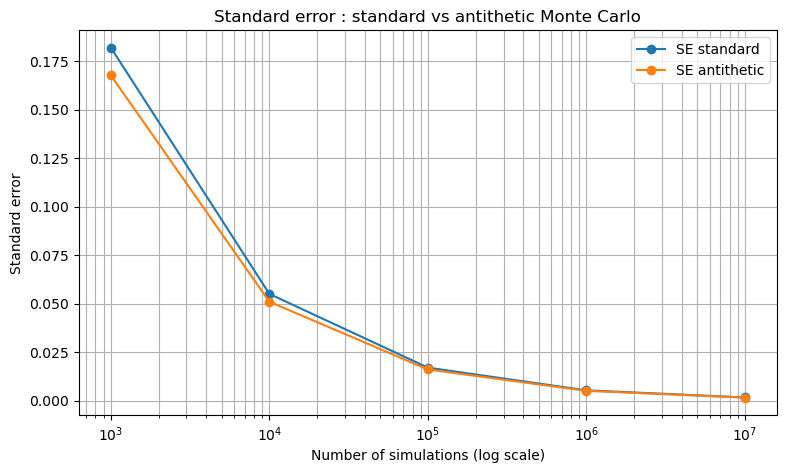

In [10]:
comparison_results = []

for N in N_values:
    standard = mc_call_price_with_ci(S0, K, T, r, sigma, N)
    antithetic = mc_call_price_antithetic(S0, K, T, r, sigma, N if N % 2 == 0 else N + 1)

    comparison_results.append({
        "N simulations": N,
        "MC standard": standard["price"],
        "SE standard": standard["se"],
        "MC antithetic": antithetic["price"],
        "SE antithetic": antithetic["se"],
        "BS price": bs_price
    })

variance_table = pd.DataFrame(comparison_results).round(6)
variance_table


#Comparison
plt.figure(figsize=(9,5))
plt.plot(variance_table["N simulations"],variance_table["MC standard"],marker="o",label="Standard Monte Carlo")
plt.plot(variance_table["N simulations"],variance_table["MC antithetic"],marker="o",label="Antithetic Monte Carlo")
plt.axhline(y=bs_price,linestyle="--",label="Black-Scholes")
plt.xscale("log")
plt.title("Standard vs antithetic Monte Carlo convergence")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Call price")
plt.legend()
plt.grid(True, which="both")
plt.show()


#Errors
plt.figure(figsize=(9,5))
plt.plot(variance_table["N simulations"],variance_table["SE standard"],marker="o",label="SE standard")
plt.plot(variance_table["N simulations"],variance_table["SE antithetic"],marker="o",label="SE antithetic")
plt.xscale("log")
plt.title("Standard error : standard vs antithetic Monte Carlo")
plt.xlabel("Number of simulations (log scale)")
plt.ylabel("Standard error")
plt.legend()
plt.grid(True, which="both")
plt.show()

## Main conclusion

The Monte Carlo estimator converges towards the Black-Scholes benchmark
as the number of simulations increases.

Confidence intervals quantify the statistical uncertainty of the estimate.

Antithetic variates improve the stability of the estimator by reducing variance.